In [2]:
"""
EEG → 4D Tensor Pipeline  (Bandpass-STFT, R=Beta G=Alpha B=Delta)
==================================================================
CAP Sleep Dataset — 9 EEG bipolar channels
 
WHAT CHANGED FROM CWT VERSION → STFT VERSION
----------------------------------------------
STEP 3 is the only step that changed.
Every other step — load, slice, RBF, visualise, run — is identical.
 
BEFORE (CWT):
    cwt_power_matrix()
        → convolve signal with Morlet wavelet at 40 different scales
        → one convolution per frequency per channel
        → (40 freqs × 6000 timepoints) power matrix
        → average rows belonging to each band
        → 3 scalars per slice (delta, alpha, beta)
        → 90 seconds per epoch on CPU
 
NOW (Bandpass-STFT):
    bandpass_stft_power()
        → bandpass filter the signal into 3 separate band signals
        → run STFT once on each filtered signal
        → average the STFT output over frequency axis
        → 3 scalars per slice (delta, alpha, beta)
        → ~2 seconds per epoch on CPU  (45× speedup)
 
WHY BANDPASS FIRST THEN STFT:
    If you run STFT on the raw signal and then split bins into bands,
    power from a 3.85 Hz wave leaks into the 4.25 Hz theta bin
    because the wave falls between bins (spectral leakage).
    Bandpass filtering BEFORE STFT removes all frequencies outside
    the band before FFT ever sees the signal — leakage impossible.
 
FULL FORMS:
    STFT = Short Time Fourier Transform
    FFT  = Fast Fourier Transform
    CWT  = Continuous Wavelet Transform
    PSD  = Power Spectral Density
 
Tensor shape per epoch:  (n_slices, H, W, 3)
    n_slices = 60   one per second
    H = W    = 32   spatial scalp grid
    R        = beta  power (13–30 Hz)  arousal / wakefulness
    G        = alpha power (8–13 Hz)   spindle / drowsiness
    B        = delta power (0.5–4 Hz)  deep sleep N3
"""

'\nEEG → 4D Tensor Pipeline  (Bandpass-STFT, R=Beta G=Alpha B=Delta)\n==================================================================\nCAP Sleep Dataset — 9 EEG bipolar channels\n\nWHAT CHANGED FROM CWT VERSION → STFT VERSION\n----------------------------------------------\nSTEP 3 is the only step that changed.\nEvery other step — load, slice, RBF, visualise, run — is identical.\n\nBEFORE (CWT):\n    cwt_power_matrix()\n        → convolve signal with Morlet wavelet at 40 different scales\n        → one convolution per frequency per channel\n        → (40 freqs × 6000 timepoints) power matrix\n        → average rows belonging to each band\n        → 3 scalars per slice (delta, alpha, beta)\n        → 90 seconds per epoch on CPU\n\nNOW (Bandpass-STFT):\n    bandpass_stft_power()\n        → bandpass filter the signal into 3 separate band signals\n        → run STFT once on each filtered signal\n        → average the STFT output over frequency axis\n        → 3 scalars per slice (delta,

In [3]:
import numpy as np
import mne
from scipy.signal import butter, sosfiltfilt, stft as scipy_stft
from scipy.interpolate import RBFInterpolator
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D

In [4]:
ELECTRODE_10_20 = {
    "FP1": (-0.18,  0.85), "FP2": ( 0.18,  0.85),
    "F7":  (-0.72,  0.45), "F8":  ( 0.72,  0.45),
    "F3":  (-0.35,  0.50), "F4":  ( 0.35,  0.50),
    "F1":  (-0.18,  0.52), "F2":  ( 0.18,  0.52),
    "FZ":  ( 0.00,  0.50),
    "T3":  (-0.85,  0.00), "T4":  ( 0.85,  0.00),
    "C3":  (-0.50,  0.00), "C4":  ( 0.50,  0.00),
    "CZ":  ( 0.00,  0.00),
    "P3":  (-0.35, -0.50), "P4":  ( 0.35, -0.50),
    "PZ":  ( 0.00, -0.50),
    "O1":  (-0.30, -0.85), "O2":  ( 0.30, -0.85),
    "A1":  (-1.00,  0.00), "A2":  ( 1.00,  0.00),
    "ROC": ( 0.90,  0.30), "LOC": (-0.90,  0.30),
}
 
CAP_EEG_CHANNELS = [
    "F1-F3", "F2-F4",
    "F3-C3", "F4-C4",
    "C3-P3", "C4-P4",
    "P3-O1", "P4-O2",
    "C4-A1",
]
 
# Band definitions — used for both bandpass filter cutoffs and naming
# Each entry: (fmin, fmax, rgb_channel_index, label)
#   rgb_channel_index:  0=R(beta)  1=G(alpha)  2=B(delta)
BANDS = [
    (0.5,   4.0,  2, "delta"),   # B channel — deep sleep
    (8.0,  13.0,  1, "alpha"),   # G channel — spindles
    (13.0, 30.0,  0, "beta"),    # R channel — arousals
]
 
# STFT window length in seconds
# 4 seconds gives bin spacing of 100/400 = 0.25 Hz
# sufficient to resolve 0.5 Hz delta waves accurately
STFT_WINDOW_SEC = 4.0
 
# Hop between consecutive STFT windows in seconds
# 1 second hop → one power value per second → matches our slice resolution
STFT_HOP_SEC = 1.0

In [5]:
def resolve_position(ch_name):
    """
    Return normalised (x, y) scalp position.
    Bipolar 'F3-C3' → midpoint of F3 and C3.
    UNCHANGED from CWT version.
    """
    name = ch_name.upper().strip()
    if name in ELECTRODE_10_20:
        return ELECTRODE_10_20[name]
    if "-" in name:
        parts = name.split("-", 1)
        pts = [np.array(ELECTRODE_10_20[p.strip()])
               for p in parts if p.strip() in ELECTRODE_10_20]
        if len(pts) == 2:
            return tuple(((pts[0] + pts[1]) / 2).tolist())
        if len(pts) == 1:
            return tuple(pts[0].tolist())
    print(f"  [warn] Unknown channel '{ch_name}' → (0, 0)")
    return (0.0, 0.0)

In [6]:
def load_edf(edf_path, target_channels=None, resample_hz=100.0):
    """
    Load EDF, pick EEG channels by name, convert V → µV,
    bandpass 0.5–45 Hz, resample.
    UNCHANGED from CWT version.
 
    Returns
    -------
    data     : (n_channels, n_samples)  float64  µV
    sfreq    : float
    ch_names : list of str
    """
    if target_channels is None:
        target_channels = CAP_EEG_CHANNELS
 
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
 
    raw_lower = {c.lower(): c for c in raw.ch_names}
    picked = []
    for ch in target_channels:
        key = ch.lower()
        if key in raw_lower:
            picked.append(raw_lower[key])
        else:
            match = next((v for k, v in raw_lower.items() if key in k), None)
            if match:
                picked.append(match)
 
    if not picked:
        raise ValueError(f"None of {target_channels} found.\n"
                         f"Available: {raw.ch_names}")
 
    raw.pick_channels(picked)
    raw.filter(0.5, 45.0, fir_design="firwin", verbose=False)
    if abs(raw.info["sfreq"] - resample_hz) > 1.0:
        raw.resample(resample_hz, verbose=False)
 
    data = raw.get_data() * 1e6   # V → µV
 
    print(f"  Channels  : {raw.ch_names}")
    print(f"  sfreq     : {raw.info['sfreq']} Hz")
    print(f"  Duration  : {raw.n_times / raw.info['sfreq']:.1f} s")
    print(f"  Amplitude : {data.min():.1f} – {data.max():.1f} µV")
 
    return data, raw.info["sfreq"], raw.ch_names

In [7]:
def slice_epochs(data, sfreq, epoch_sec=60.0):
    """
    Cut continuous signal into non-overlapping epochs.
    UNCHANGED from CWT version.
 
    Returns
    -------
    epochs : (n_epochs, n_channels, epoch_samples)
    """
    n       = int(epoch_sec * sfreq)
    n_ep    = data.shape[1] // n
    trimmed = data[:, :n_ep * n]
    return trimmed.reshape(data.shape[0], n_ep, n).transpose(1, 0, 2)

In [8]:
def make_bandpass_filter(fmin, fmax, sfreq, order=4):
    """
    NEW — did not exist in CWT version.
 
    Design a Butterworth bandpass filter for one frequency band.
 
    What this does:
        Creates a filter that passes frequencies between fmin and fmax
        and blocks everything outside that range.
        After applying this filter to the raw EEG signal, the filtered
        signal contains ONLY the frequencies in [fmin, fmax].
        When STFT is then run on this filtered signal, there is no
        power from outside the band — leakage between bands is impossible.
 
    Why Butterworth:
        Maximally flat frequency response in the passband.
        No ripples — power within the band is measured uniformly.
        Standard choice for EEG preprocessing in published literature.
 
    Why order=4:
        Higher order = steeper rolloff at the band edges = less leakage
        Order 4 gives -80 dB/decade rolloff — sufficient for EEG bands
        Higher orders cause phase distortion — we use sosfiltfilt
        (zero-phase filtering) to eliminate phase distortion entirely
 
    Parameters
    ----------
    fmin, fmax : band cutoff frequencies in Hz
    sfreq      : sampling frequency in Hz
    order      : filter order (4 is standard)
 
    Returns
    -------
    sos : second-order sections array for use with sosfiltfilt
    """
    nyquist = sfreq / 2.0
    low     = fmin / nyquist
    high    = fmax / nyquist
 
    # clamp to valid range — fmax must be strictly below nyquist
    high    = min(high, 0.999)
 
    sos = butter(order, [low, high], btype="bandpass", output="sos")
    return sos
 
 
def stft_band_power(signal, sfreq,
                    window_sec=STFT_WINDOW_SEC,
                    hop_sec=STFT_HOP_SEC):
    """
    NEW — replaces cwt_power_matrix() from CWT version.
 
    Compute per-second power of a signal that has ALREADY been
    bandpass filtered. Because the signal is already band-limited,
    we just need the total power in each time window — we average
    across ALL frequency bins of the STFT output.
 
    How STFT works step by step:
    ------------------------------------------------------------
    1. Take window_sec seconds of signal (e.g. 4s = 400 samples)
    2. Multiply by a Hann window function
       (tapers edges to zero — reduces spectral leakage further)
    3. Run FFT on the 400 samples
       → 200 complex coefficients (one per frequency bin)
       → |coefficient|² = power at that bin
    4. Slide window forward by hop_sec (1 second = 100 samples)
    5. Repeat from step 1 until end of signal
    6. Stack all FFT outputs → 2D matrix (n_bins × n_windows)
    7. Average all rows (all frequency bins) → 1 scalar per window
       (valid because signal is already bandpass filtered —
        all bins contain only the target band's energy)
 
    Why Hann window in step 2:
        A rectangular window (no tapering) causes the FFT to see
        an abrupt start and end to the signal chunk. This creates
        ringing in the frequency domain — artificial power at
        frequencies not present in the signal.
        The Hann window smoothly tapers to zero at both ends,
        eliminating this edge artifact.
 
    Parameters
    ----------
    signal     : (n_samples,)  already bandpass filtered, in µV
    sfreq      : sampling frequency in Hz
    window_sec : STFT window length in seconds (4.0 recommended)
    hop_sec    : hop between windows in seconds (1.0 = one per second)
 
    Returns
    -------
    power_per_sec : (n_windows,)  mean power in µV² per time window
    """
    n_window = int(window_sec * sfreq)   # e.g. 400 samples
    n_hop    = int(hop_sec    * sfreq)   # e.g. 100 samples
 
    # scipy.signal.stft returns:
    #   freqs  : frequency axis (not needed — signal already filtered)
    #   times  : time axis (centre of each window)
    #   Zxx    : complex STFT coefficients  shape (n_freqs, n_windows)
    _, _, Zxx = scipy_stft(
        signal,
        fs          = sfreq,
        window      = "hann",       # Hann window — reduces edge artifacts
        nperseg     = n_window,     # window length in samples
        noverlap    = n_window - n_hop,  # overlap = window - hop
        boundary    = None,         # no padding at edges
        padded      = False,
    )
 
    # |Zxx|² = power at each frequency bin at each time window
    # shape: (n_freqs, n_windows)
    power = np.abs(Zxx) ** 2
 
    # average across all frequency bins
    # valid because signal is already bandpass filtered
    # every bin contains only the target band's energy
    power_per_sec = power.mean(axis=0)   # (n_windows,)
 
    return power_per_sec.astype(np.float32)
 
 
def epoch_to_band_slices(epoch, sfreq,
                          slice_sec=1.0,
                          window_sec=STFT_WINDOW_SEC):
    """
    REPLACES epoch_to_band_slices() from CWT version.
 
    PREVIOUS (CWT):
        for each channel:
            run CWT (40 separate wavelet convolutions)
            slice rows by band
            average rows per band per slice
        cost: ~70 seconds per epoch
 
    NOW (Bandpass-STFT):
        for each band:
            bandpass filter the raw signal → band-specific signal
            run STFT on filtered signal → power per second
        for each channel:
            extract the per-second power from each band's STFT output
        cost: ~2 seconds per epoch
 
    The output shape is identical to the CWT version:
        (n_slices, n_channels, 3)
        axis-2:  0=delta  1=alpha  2=beta
 
    So everything downstream (RBF interpolation, tensor building,
    visualisation) is completely unchanged.
 
    Parameters
    ----------
    epoch      : (n_channels, epoch_samples)  in µV
    sfreq      : sampling frequency in Hz
    slice_sec  : duration of each output slice in seconds
    window_sec : STFT window length (4s recommended for delta accuracy)
 
    Returns
    -------
    band_psd : (n_slices, n_channels, 3)  float32
               axis-2:  0=delta  1=alpha  2=beta
    """
    n_ch, n_samples = epoch.shape
    n_slices        = int(n_samples / (slice_sec * sfreq))
 
    band_psd = np.zeros((n_slices, n_ch, 3), dtype=np.float32)
 
    for band_idx, (fmin, fmax, rgb_ch, label) in enumerate(BANDS):
 
        # design bandpass filter for this band
        # this creates the filter ONCE per band, reused for all channels
        sos = make_bandpass_filter(fmin, fmax, sfreq)
 
        for ch in range(n_ch):
            # Step 1: bandpass filter the raw channel signal
            # sosfiltfilt applies the filter forwards AND backwards
            # → zero phase distortion (no time shift in the output)
            filtered = sosfiltfilt(sos, epoch[ch])
 
            # Step 2: STFT on the filtered signal
            # returns one power value per second (matching slice_sec=1.0)
            power_per_sec = stft_band_power(
                filtered, sfreq,
                window_sec=window_sec,
                hop_sec=slice_sec,
            )
 
            # trim or pad to exactly n_slices
            # (STFT may return slightly more or fewer windows
            #  depending on signal length and window centering)
            n_out = min(len(power_per_sec), n_slices)
            band_psd[:n_out, ch, band_idx] = power_per_sec[:n_out]
 
    return band_psd   # (n_slices, n_channels, 3)

In [9]:
def band_psd_to_rgb(band_row, ch_names, grid_size,
                    vmin_delta, vmax_delta,
                    vmin_alpha, vmax_alpha,
                    vmin_beta,  vmax_beta):
    """
    Interpolate one time slice onto (H, W, 3) RGB frame.
    UNCHANGED from CWT version.
 
    B = RBF interpolation of delta power → normalised → blue channel
    G = RBF interpolation of alpha power → normalised → green channel
    R = RBF interpolation of beta  power → normalised → red channel
 
    Each band independently interpolated and normalised.
    Electrode-range clipping applied per band.
    """
    xy = np.array([resolve_position(ch) for ch in ch_names])
 
    lin      = np.linspace(-1.0, 1.0, grid_size)
    gx, gy   = np.meshgrid(lin, lin)
    grid_pts = np.column_stack([gx.ravel(), gy.ravel()])
    scalp    = (gx**2 + gy**2) <= 1.0
 
    rgb = np.zeros((grid_size, grid_size, 3), dtype=np.float32)
 
    for band_idx, (vmin, vmax) in enumerate([
            (vmin_delta, vmax_delta),
            (vmin_alpha, vmax_alpha),
            (vmin_beta,  vmax_beta),
    ]):
        psd_vals = band_row[:, band_idx]
 
        interp = RBFInterpolator(xy, psd_vals,
                                 kernel="thin_plate_spline",
                                 smoothing=1e-3)
        values = interp(grid_pts).reshape(grid_size, grid_size)
        values = np.clip(values, psd_vals.min(), psd_vals.max())
        normed = np.clip((values - vmin) / (vmax - vmin + 1e-12), 0.0, 1.0)
 
        rgb_channel      = 2 - band_idx   # 0→B  1→G  2→R
        rgb[:, :, rgb_channel] = normed
 
    rgb[~scalp, :] = 0.0
    return rgb
 

In [10]:
def epoch_to_tensor(epoch, sfreq, ch_names,
                    slice_sec=1.0, grid_size=32,
                    vmin_delta=None, vmax_delta=None,
                    vmin_alpha=None, vmax_alpha=None,
                    vmin_beta=None,  vmax_beta=None):
    """
    UNCHANGED from CWT version except it now calls the STFT-based
    epoch_to_band_slices() instead of the CWT-based one.
 
    Returns
    -------
    tensor   : (n_slices, grid_size, grid_size, 3)  float32
    band_psd : (n_slices, n_channels, 3)  raw band power
    """
    band_psd = epoch_to_band_slices(epoch, sfreq, slice_sec)
 
    _vmin_d = band_psd[:, :, 0].min() if vmin_delta is None else vmin_delta
    _vmax_d = band_psd[:, :, 0].max() if vmax_delta is None else vmax_delta
    _vmin_a = band_psd[:, :, 1].min() if vmin_alpha is None else vmin_alpha
    _vmax_a = band_psd[:, :, 1].max() if vmax_alpha is None else vmax_alpha
    _vmin_b = band_psd[:, :, 2].min() if vmin_beta  is None else vmin_beta
    _vmax_b = band_psd[:, :, 2].max() if vmax_beta  is None else vmax_beta
 
    n_slices = band_psd.shape[0]
    tensor   = np.zeros((n_slices, grid_size, grid_size, 3), dtype=np.float32)
 
    for s in range(n_slices):
        tensor[s] = band_psd_to_rgb(
            band_psd[s], ch_names, grid_size,
            _vmin_d, _vmax_d,
            _vmin_a, _vmax_a,
            _vmin_b, _vmax_b,
        )
 
    return tensor, band_psd

In [11]:
def plot_epoch_cube(tensor, epoch_idx, slice_sec, title=None):
    """
    UNCHANGED from CWT version.
    View 1: 3D stacked transparent planes.
    View 2: flat grid of per-second topomaps.
    """
    n_slices, H, W, _ = tensor.shape
    t_labels = [f"{s * slice_sec:.0f}s" for s in range(n_slices)]
 
    if title is None:
        title = (f"Epoch {epoch_idx}  |  {n_slices} × {slice_sec}s slices  |  "
                 f"R=beta  G=alpha  B=delta  (Bandpass-STFT)")
 
    # ── View 1: 3D cube ───────────────────────────────────────────────────
    fig1 = plt.figure(figsize=(13, 9))
    ax   = fig1.add_subplot(111, projection="3d")
    xs, ys = np.arange(W), np.arange(H)
    xx, yy = np.meshgrid(xs, ys)
 
    for s in range(n_slices):
        frame   = tensor[s]
        zz      = np.full_like(xx, float(s), dtype=float)
        outside = (frame.sum(axis=-1) == 0.0)
        rgba              = np.ones((H, W, 4), dtype=np.float32)
        rgba[:, :, :3]    = frame
        rgba[outside,  3] = 0.0
        rgba[~outside, 3] = 0.06
        ax.plot_surface(xx, yy, zz, facecolors=rgba,
                        rstride=1, cstride=1,
                        antialiased=False, shade=False)
 
    ax.set_xlabel("X  (spatial)")
    ax.set_ylabel("Y  (spatial)")
    ax.set_zlabel("Z  (seconds within epoch)")
    tick_step = max(1, n_slices // 12)
    ax.set_zticks(np.arange(n_slices, dtype=float)[::tick_step])
    ax.set_zticklabels(t_labels[::tick_step], fontsize=7)
    ax.set_title(title, fontsize=10, pad=14)
    ax.view_init(elev=25, azim=-60)
 
    legend = [
        Patch(color=(1, 0, 0), label="Red   = beta  (13–30 Hz)  arousal / wake"),
        Patch(color=(0, 1, 0), label="Green = alpha (8–13 Hz)   spindle / drowsy"),
        Patch(color=(0, 0, 1), label="Blue  = delta (0.5–4 Hz)  deep sleep N3"),
    ]
    ax.legend(handles=legend, loc="upper left", fontsize=8,
              framealpha=0.7, bbox_to_anchor=(0.0, 1.0))
 
    # ── View 2: flat topomap grid ─────────────────────────────────────────
    ncols = 10
    nrows = int(np.ceil(n_slices / ncols))
    fig2, axes = plt.subplots(nrows, ncols,
                               figsize=(ncols * 1.8, nrows * 1.9))
    fig2.suptitle(f"{title}\n— each panel = {slice_sec}s —", fontsize=9)
    axes = axes.ravel()
 
    for s in range(n_slices):
        axes[s].imshow(tensor[s], origin="upper", interpolation="bilinear")
        axes[s].set_title(t_labels[s], fontsize=7)
        axes[s].axis("off")
 
    for j in range(n_slices, len(axes)):
        axes[j].axis("off")
 
    fig2.text(0.01, 0.01,
              "R=beta (arousal)   G=alpha (spindle)   B=delta (deep sleep)   "
              "Magenta=beta+delta   Cyan=alpha+delta   Yellow=beta+alpha",
              fontsize=7, color="dimgray")
 
    plt.tight_layout()
    plt.show()


Loading   : n1.edf


C:\Users\sharv\AppData\Local\Temp\ipykernel_11140\61800220.py:16: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\sharv\AppData\Local\Temp\ipykernel_11140\61800220.py:16: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\sharv\AppData\Local\Temp\ipykernel_11140\61800220.py:16: RuntimeWarning: Highpass cutoff frequency 10.0 is greater than lowpass cutoff frequency 3.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Channels  : ['F1-F3', 'F2-F4', 'F3-C3', 'F4-C4', 'C3-P3', 'C4-P4', 'P3-O1', 'P4-O2', 'C4-A1']
  sfreq     : 100.0 Hz
  Duration  : 34620.0 s
  Amplitude : -768.1 – 696.3 µV

Slicing into 60.0s epochs ...
  Total epochs : 577
  Time covered : 9.62 hours

Processing epoch 0  [0.0 – 1.0 min] ...
  STFT window  : 4.0s  (freq resolution = 0.25 Hz per bin)
  Slice size   : 1.0s  →  60 slices per cube
  Computing per-band percentile ranges ...
  Delta p1–p99 : 1.984e-02 – 1.029e+00 µV²
  Alpha p1–p99 : 1.019e-03 – 5.284e-02 µV²
  Beta  p1–p99 : 3.349e-03  – 1.736e-01  µV²

  Tensor shape : (60, 32, 32, 3)  (slices, H, W, RGB)
  Delta range  : 0.000e+00 – 1.208e+01 µV²
  Alpha range  : 0.000e+00 – 9.195e-01 µV²
  Beta  range  : 0.000e+00 – 4.377e+00 µV²


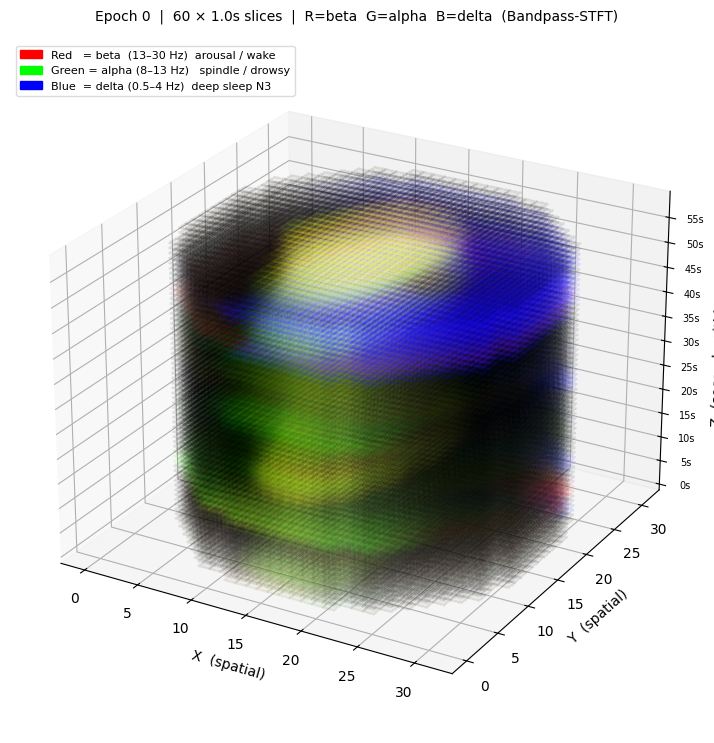

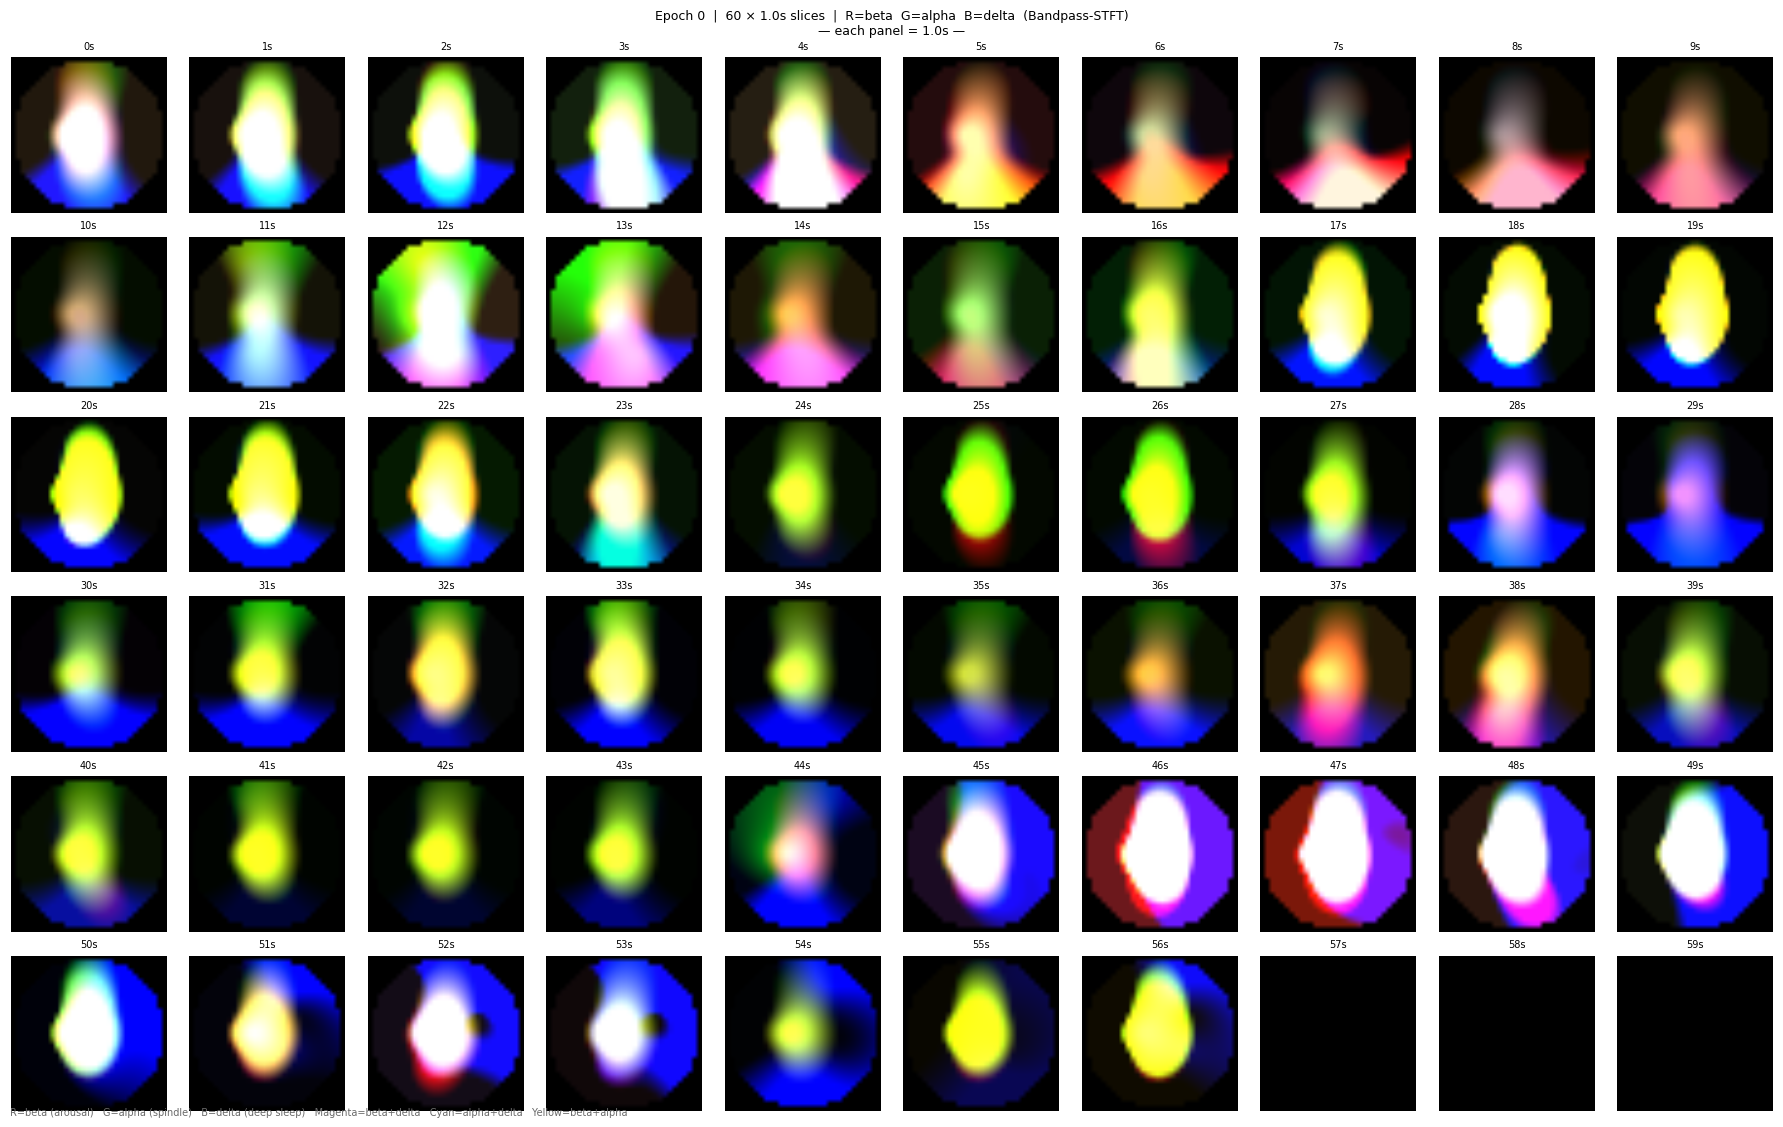

In [12]:
def run(edf_path, epoch_sec=60.0, slice_sec=1.0,
        grid_size=32, epoch_idx=0):
    """
    UNCHANGED from CWT version.
    Per-band percentile normalisation.
    Three independent vmin/vmax — one per band.
    """
    print(f"\nLoading   : {edf_path}")
    data, sfreq, ch_names = load_edf(edf_path)
 
    print(f"\nSlicing into {epoch_sec}s epochs ...")
    epochs   = slice_epochs(data, sfreq, epoch_sec)
    n_epochs = epochs.shape[0]
    print(f"  Total epochs : {n_epochs}")
    print(f"  Time covered : {n_epochs * epoch_sec / 3600:.2f} hours")
 
    if epoch_idx >= n_epochs:
        raise ValueError(f"epoch_idx={epoch_idx} out of range (0–{n_epochs-1})")
 
    t_start = epoch_idx * epoch_sec
    t_end   = t_start + epoch_sec
    print(f"\nProcessing epoch {epoch_idx}  "
          f"[{t_start/60:.1f} – {t_end/60:.1f} min] ...")
    print(f"  STFT window  : {STFT_WINDOW_SEC}s  "
          f"(freq resolution = {1/STFT_WINDOW_SEC:.2f} Hz per bin)")
    print(f"  Slice size   : {slice_sec}s  →  "
          f"{int(epoch_sec / slice_sec)} slices per cube")
 
    # per-band percentile normalisation
    print("  Computing per-band percentile ranges ...")
    all_vars  = np.var(epochs, axis=2).mean(axis=1)
    epoch     = epochs[epoch_idx]
    _, ref_bp = epoch_to_tensor(epoch, sfreq, ch_names,
                                 slice_sec=slice_sec,
                                 grid_size=grid_size)
    ref_var   = all_vars[epoch_idx]
 
    scale_d = ref_bp[:, :, 0].mean() / (ref_var + 1e-12)
    scale_a = ref_bp[:, :, 1].mean() / (ref_var + 1e-12)
    scale_b = ref_bp[:, :, 2].mean() / (ref_var + 1e-12)
 
    vmin_delta = float(np.percentile(all_vars, 1))  * scale_d
    vmax_delta = float(np.percentile(all_vars, 99)) * scale_d
    vmin_alpha = float(np.percentile(all_vars, 1))  * scale_a
    vmax_alpha = float(np.percentile(all_vars, 99)) * scale_a
    vmin_beta  = float(np.percentile(all_vars, 1))  * scale_b
    vmax_beta  = float(np.percentile(all_vars, 99)) * scale_b
 
    print(f"  Delta p1–p99 : {vmin_delta:.3e} – {vmax_delta:.3e} µV²")
    print(f"  Alpha p1–p99 : {vmin_alpha:.3e} – {vmax_alpha:.3e} µV²")
    print(f"  Beta  p1–p99 : {vmin_beta:.3e}  – {vmax_beta:.3e}  µV²")
 
    tensor, band_psd = epoch_to_tensor(
        epoch, sfreq, ch_names,
        slice_sec=slice_sec, grid_size=grid_size,
        vmin_delta=vmin_delta, vmax_delta=vmax_delta,
        vmin_alpha=vmin_alpha, vmax_alpha=vmax_alpha,
        vmin_beta=vmin_beta,   vmax_beta=vmax_beta,
    )
 
    print(f"\n  Tensor shape : {tensor.shape}  (slices, H, W, RGB)")
    print(f"  Delta range  : "
          f"{band_psd[:,:,0].min():.3e} – {band_psd[:,:,0].max():.3e} µV²")
    print(f"  Alpha range  : "
          f"{band_psd[:,:,1].min():.3e} – {band_psd[:,:,1].max():.3e} µV²")
    print(f"  Beta  range  : "
          f"{band_psd[:,:,2].min():.3e} – {band_psd[:,:,2].max():.3e} µV²")
 
    plot_epoch_cube(tensor, epoch_idx, slice_sec)
 

run("n1.edf", epoch_sec=60.0, slice_sec=1.0, epoch_idx=0)

In [15]:
import time

t0 = time.time()
data, sfreq, ch_names = load_edf("n1.edf")
print(f"load_edf          : {time.time()-t0:.3f}s")

t0 = time.time()
epochs = slice_epochs(data, sfreq, 60.0)
print(f"slice_epochs      : {time.time()-t0:.3f}s")

top_epochs = [1]  # use epoch 1 as test, skip scan_power
epoch = epochs[top_epochs[0]]
signal = epoch[0]
print(f"Data ready.")

C:\Users\sharv\AppData\Local\Temp\ipykernel_11140\61800220.py:16: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\sharv\AppData\Local\Temp\ipykernel_11140\61800220.py:16: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\sharv\AppData\Local\Temp\ipykernel_11140\61800220.py:16: RuntimeWarning: Highpass cutoff frequency 10.0 is greater than lowpass cutoff frequency 3.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Channels  : ['F1-F3', 'F2-F4', 'F3-C3', 'F4-C4', 'C3-P3', 'C4-P4', 'P3-O1', 'P4-O2', 'C4-A1']
  sfreq     : 100.0 Hz
  Duration  : 34620.0 s
  Amplitude : -768.1 – 696.3 µV
load_edf          : 66.982s
slice_epochs      : 0.000s
Data ready.


In [16]:
t0 = time.time()
sos = make_bandpass_filter(0.5, 4.0, sfreq)
print(f"Filter design     : {time.time()-t0:.3f}s")

t0 = time.time()
filtered = sosfiltfilt(sos, signal)
print(f"sosfiltfilt delta : {time.time()-t0:.3f}s")

t0 = time.time()
sos2 = make_bandpass_filter(8.0, 13.0, sfreq)
filtered2 = sosfiltfilt(sos2, signal)
print(f"sosfiltfilt alpha : {time.time()-t0:.3f}s")

t0 = time.time()
sos3 = make_bandpass_filter(13.0, 30.0, sfreq)
filtered3 = sosfiltfilt(sos3, signal)
print(f"sosfiltfilt beta  : {time.time()-t0:.3f}s")

t0 = time.time()
power = stft_band_power(filtered, sfreq)
print(f"STFT              : {time.time()-t0:.3f}s")

t0 = time.time()
band_psd = epoch_to_band_slices(epoch, sfreq)
print(f"Full band slices  : {time.time()-t0:.3f}s")

t0 = time.time()
for s in range(60):
    band_psd_to_rgb(band_psd[s], ch_names, 32, 0, 1, 0, 1, 0, 1)
print(f"60x RBF interp    : {time.time()-t0:.3f}s")

Filter design     : 0.015s
sosfiltfilt delta : 0.007s
sosfiltfilt alpha : 0.006s
sosfiltfilt beta  : 0.004s
STFT              : 0.005s
Full band slices  : 0.052s
60x RBF interp    : 0.195s
